In [2]:
#!pip install matplotlib

Shapiro's test for Tiktok:(np.float64(0.9340696654752974), np.float64(0.003965103993596213))
Levene's test:(np.float64(45.56303571327507), np.float64(1.5525527208552062e-16))
t-statistic for Tiktok vs Facebook: -1.7419211873617955
P-value: 0.08701268231873392
t-statistic for Tiktok vs Population: -1.169094823576504
P-value: 0.24731783681379704
Wilcoxon-statistic for Tiktok vs Facebook: 653.0
P-value: 0.1680509414439949
Wilcoxon-statistic for Tiktok vs Population: 706.0
P-value: 0.3383666221471511


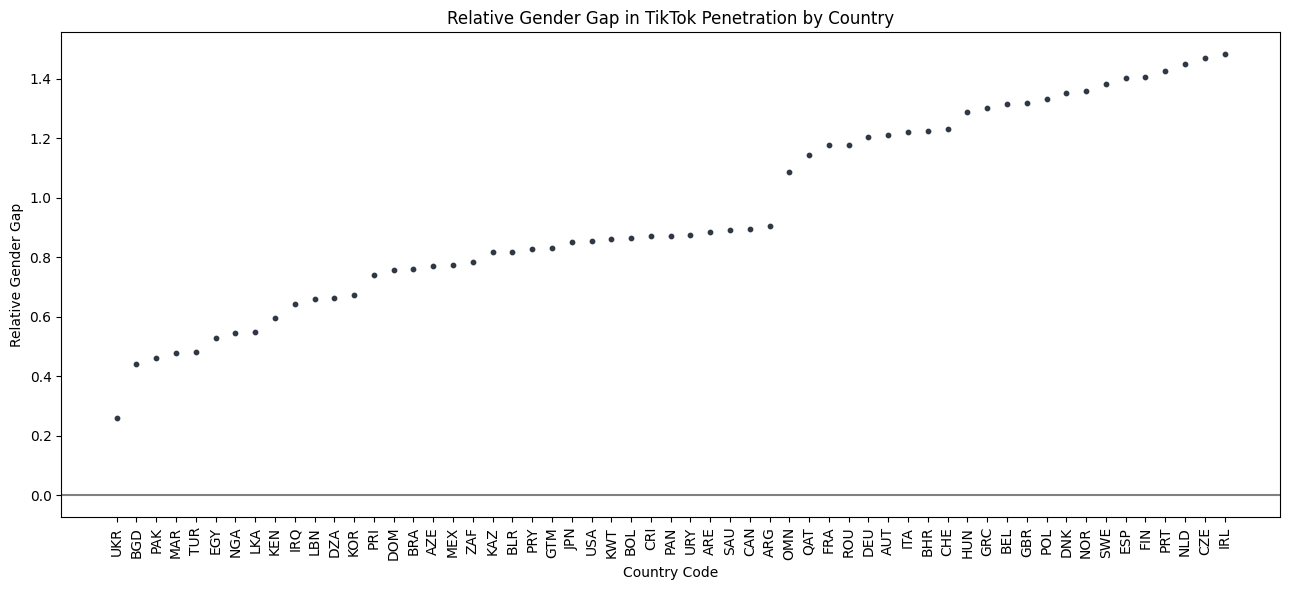

In [30]:
#### Statistical Tests and Analyses
import math
import numpy as np
from scipy.stats import shapiro, ttest_rel, levene, wilcoxon
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

TT = Path("../outputs/gap_by_country.csv")
FB = Path("../merged_fb.csv")

tt_df = pd.read_csv(TT, encoding="utf-8-sig")
fb_df = pd.read_csv(FB, encoding="utf-8-sig")

#perform Shapiro-Wilk test for normality, H0=normal distribution, If the p-value of the test > α = .05, then the data is assumed to be normally distributed
tiktok = tt_df["tt_fm"]
stat, p = shapiro(tiktok)
print(f"Shapiro's test for Tiktok:{stat, p}")

#test homogeneity of variance, H0=euqal variance, homoscedastic, if we get a p-value > 0.05 we can assume that our data is heteroscedastic (which is what we want)
facebook = fb_df["fb_fm"]
population = tt_df["pop_fm"]

stat, p = levene(tiktok, facebook, population)

print(f"Levene's test:{stat, p}")

# Perform two-sample paired t-test if assumptions are met

t_statistic_ft, p_value_ft = ttest_rel(tiktok, facebook)
t_statistic_pt, p_value_pt = ttest_rel(tiktok, population)

# Output the results
print(f"t-statistic for Tiktok vs Facebook: {t_statistic_ft}")
print(f"P-value: {p_value_ft}")

print(f"t-statistic for Tiktok vs Population: {t_statistic_pt}")
print(f"P-value: {p_value_pt}")

# Perform Wilcoxon test if assumptions are not met

t_statistic_ft, p_value_ft = wilcoxon(tiktok, facebook)
t_statistic_pt, p_value_pt = wilcoxon(tiktok, population)

# Output the results
print(f"Wilcoxon-statistic for Tiktok vs Facebook: {t_statistic_ft}")
print(f"P-value: {p_value_ft}")

print(f"Wilcoxon-statistic for Tiktok vs Population: {t_statistic_pt}")
print(f"P-value: {p_value_pt}")


### Create Scatterplot of Tiktok Relative Gender Gap
tt_df_sorted = tt_df.sort_values("relative_gap", ascending=True)
plt.figure(figsize=(13, 6))
plt.scatter(tt_df_sorted["country_code"], tt_df_sorted["relative_gap"],color='#303845', s=10)

# Add horizontal line at 0 to show baseline
plt.axhline(0, color='gray')

# Labels and title
plt.xticks(rotation=90)
plt.xlabel("Country Code")
plt.ylabel("Relative Gender Gap")
plt.title("Relative Gender Gap in TikTok Penetration by Country")
plt.tight_layout()
plt.grid(False)
plt.show()

Shapiro: reject H0 -> tiktok data not normally distributed <br>
Levene: reject H0 -> different variances, heteroscedastic <br>
Wilcoxon: both p-values are >.05, fail to reject H0, Tiktok values are not statistically different from the facebook or population values <br>
The results showed no statistically significant difference between TikTok and Facebook gender ratios (Wilcoxon statistic = 681.0, p > 0.05), nor between TikTok and the population gender ratios (Wilcoxon statistic = 735.0, p >0.05).


In [8]:
# compare audience estimates to population
# descriptive table summary:
######## N countries, min, max, mean, sd
#Gender + Overall
# TT Pen
# TT Gap
# Pop Gap
# Rel Gap

tbl = pd.read_csv("../outputs/summary_table.csv")

import pandas as pd

# Load summary table
tbl = pd.read_csv("../outputs/summary_table.csv")

# Mapping original variable names to multi-level rows
mapping = {
    'tiktok_female':    ('Female', 'TikTok aud. estimate'),
    'pen_female':       ('Female', 'TikTok Penetration \%'),
    #'pop_female':       ('Female', 'Population'),
    
    'tiktok_male':      ('Male', 'TikTok  aud. estimate'),
    'pen_male':         ('Male', 'TikTok Penetration \%'),
    #'pop_male':         ('Male', 'Population'),
    
    'tiktok_total':     ('Total', 'TikTok  aud. estimate'),
    'pen_total':        ('Total', 'TikTok Penetration \%'),
    'pop_total':        ('Total', 'Population'),
    'tt_fm':            ('Total', 'TikTok Gender Gap'),
    #'pop_fm':           ('Total', 'Population Gender Gap'),
    'gap_index':        ('Total', 'Relative Gender Gap'),
}

# Subset and rename for LaTeX-ready table
rows = []
for var, (gender, label) in mapping.items():
    row = tbl[tbl['Variable'] == var].iloc[0]
    rows.append({
        'Gender': gender,
        'Variable': label,
        'N': f"{int(round(row['count'])):,}",
        'Mean': f"{row['mean']:,.2f}",
        'SD': f"{row['std']:,.2f}",
        'Min': f"{row['min']:,.2f}",
        'Max': f"{row['max']:,.2f}",
    })

# Create clean DataFrame
latex_df = pd.DataFrame(rows)

# Replace repeated gender with blank for grouping display
latex_df['Gender'] = latex_df['Gender'].mask(latex_df['Gender'].duplicated(), '')

# Create LaTeX table string
latex_str = latex_df.to_latex(
    index=False,
    column_format='l l r r r r r',
    float_format="%.2f",
    escape=False,
    header=['Gender', 'Variable', 'N', 'Mean', 'SD', 'Min', 'Max']
)

# Insert booktabs rules for nicer styling
latex_str = latex_str.replace('\\toprule', '\\toprule')\
                     .replace('\\midrule', '\\midrule')\
                     .replace('\\bottomrule', '\\bottomrule')

# Save to .tex file
with open("../outputs/publication_ready_table.tex", "w") as f:
    f.write(latex_str)

# Optional: print
print(latex_str)



\begin{tabular}{l l r r r r r}
\toprule
Gender & Variable & N & Mean & SD & Min & Max \\
\midrule
Female & TikTok aud. estimate & 342 & 2,154,073.10 & 4,036,201.22 & 500.00 & 34,977,000.00 \\
 & TikTok Penetration \% & 342 & 0.98 & 1.12 & 0.00 & 6.32 \\
Male & TikTok  aud. estimate & 342 & 3,219,641.81 & 6,854,665.89 & 500.00 & 50,305,500.00 \\
 & TikTok Penetration \% & 342 & 1.26 & 3.10 & 0.00 & 50.13 \\
Total & TikTok  aud. estimate & 342 & 5,373,714.91 & 10,552,845.71 & 1,000.00 & 75,091,000.00 \\
 & TikTok Penetration \% & 342 & 1.12 & 1.96 & 0.00 & 27.74 \\
 & Population & 342 & 5,248,442.30 & 7,831,596.63 & 91,228.00 & 46,117,319.00 \\
 & TikTok Gender Gap & 342 & 0.96 & 0.32 & 0.09 & 1.91 \\
 & Relative Gender Gap & 342 & 1.02 & 0.33 & 0.09 & 2.36 \\
\bottomrule
\end{tabular}



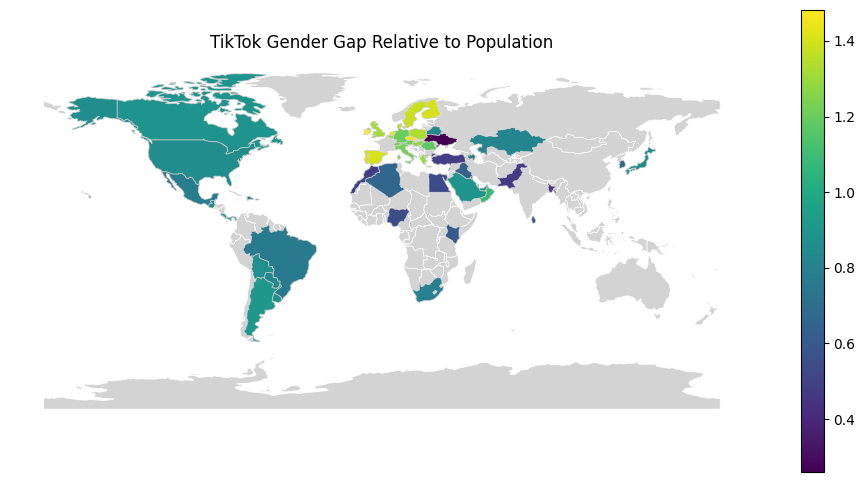

In [53]:
# creating map of tiktok 
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Example data
df = pd.read_csv("../outputs/gap_by_country.csv")
df = df[["country_code","relative_gap"]]

# Load world geometry
world = gpd.read_file("map/ne_110m_admin_0_countries.shp")

# Merge
df = df.rename(columns={"country_code": "ISO_A3"})
merged = world.merge(df, on='ISO_A3', how='left')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
world.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.5)

merged.dropna(subset=["relative_gap"]).plot(
    column='relative_gap',
    cmap='viridis',
    linewidth=0.5,
    edgecolor='0.8',
    legend=True,
    ax=ax
)

ax.set_title('TikTok Gender Gap Relative to Population')
plt.axis('off')
plt.show()



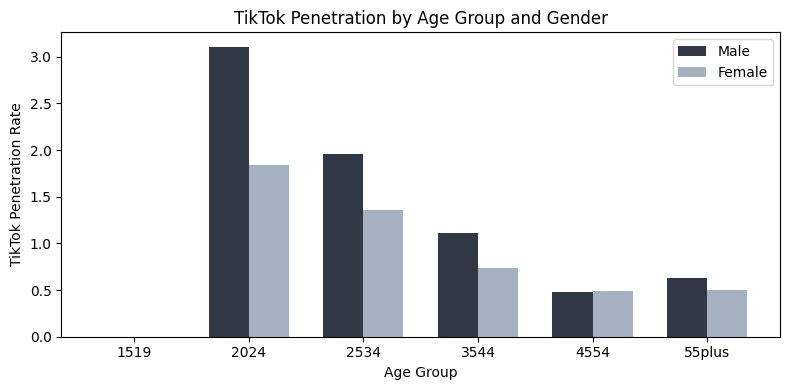

C:\Users\Hanna\AppData\Local\Temp\ipykernel_44172\1559364492.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


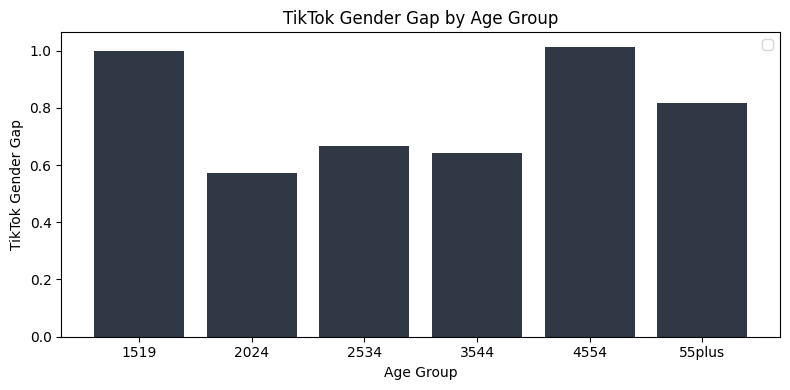

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../outputs/penetration_by_bucket.csv")
# Plot histogram of TikTok penetration by age bucket
df['bucket'] = df['bucket'].astype(str)
plt.figure(figsize=(8, 4))
x = np.arange(len(df['bucket']))  # label locations
width = 0.35
plt.bar(x - width/2, df['pen_male'], width, label='Male', color='#303845')
plt.bar(x + width/2, df['pen_female'], width, label='Female', color='#7F91A7', alpha=0.7)

# Labeling
plt.xlabel("Age Group")
plt.ylabel("TikTok Penetration Rate")
plt.title("TikTok Penetration by Age Group and Gender")
plt.xticks(x, df['bucket'])  # Set custom x-axis labels
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(df['bucket'], df['tt_fm'], color='#303845')

# Labeling
plt.xlabel("Age Group")
plt.ylabel("TikTok Gender Gap")
plt.title("TikTok Gender Gap by Age Group")
plt.legend()
plt.tight_layout()
plt.show()

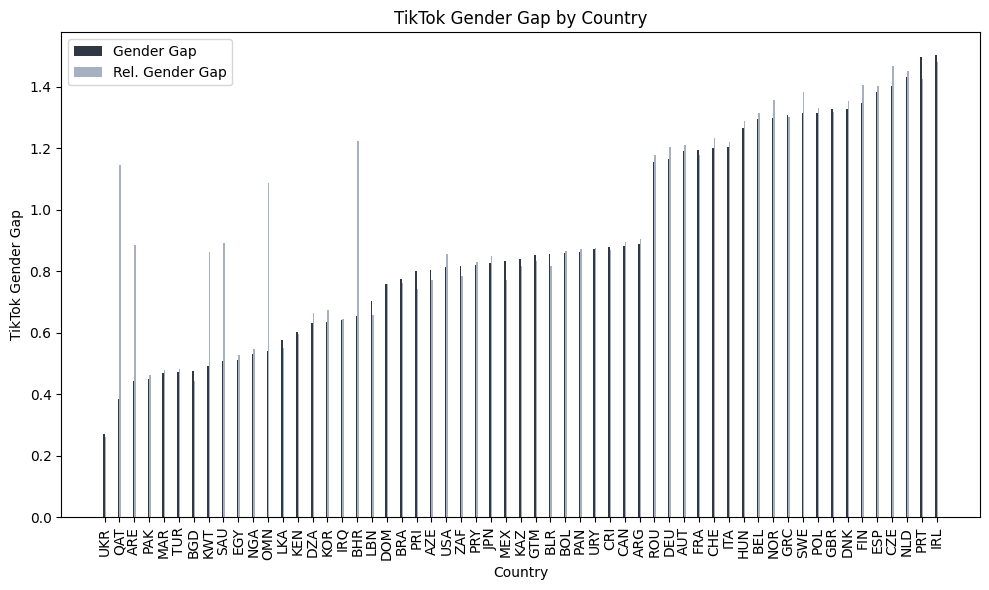

In [33]:

df = pd.read_csv("../outputs/gap_by_country.csv")
# Plot histogram of TikTok penetration by age bucket
plt.figure(figsize=(10, 6))
df = df.sort_values(by='tt_fm') 
x = np.arange(len(df['country_code']))  # label locations
width = 0.1
plt.bar(x - width/2, df['tt_fm'], width, label='Gender Gap', color='#303845')
plt.bar(x + width/2, df['relative_gap'], width, label='Rel. Gender Gap', color='#7F91A7', alpha=0.7)

# Labeling
plt.xlabel("Country")
plt.ylabel("TikTok Gender Gap")
plt.title("TikTok Gender Gap by Country")
plt.xticks(rotation=90)
plt.xticks(x, df['country_code'])
plt.legend()
plt.tight_layout()
plt.show()

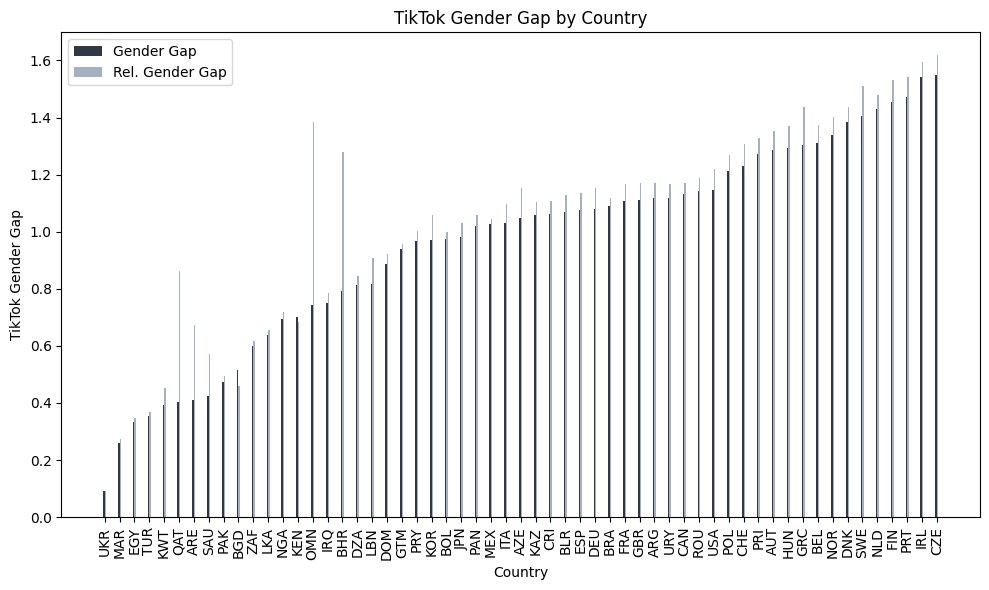

    country_code   delta_pop  delta_pop_pct
319          UKR  52869057.0      26.736071
301          SAU  19686944.0       7.322497
313          TUR  42890008.0       6.963803
199          KWT   1602850.0       6.208987
289          QAT    951504.0       6.003331
217          MAR  17665490.0       5.989297
176          JPN  62942717.0       5.181203
1            ARE   4370420.0       4.757800
302          SAU  30479457.0       4.101087
175          JPN  24284659.0       3.965916
110
Percentage of rows that have higher TikTok estimates than population: 32.16%
Avg amount TikTok estimates higher than population: 6,878,414.65
107
Percentage of rows that have higher TikTok estimates than population w/o Outlier: 31.29%
Avg amount TikTok estimates higher than population w/o Outlier: 6,361,195.43


In [52]:
df = pd.read_csv("../outputs/penetration_by_country.csv")
df_age = df[df["bucket"]=="2024"]
# Plot histogram of TikTok penetration by age bucket
plt.figure(figsize=(10, 6))
df_age = df_age.sort_values(by='tt_fm') 
x = np.arange(len(df_age['country_code']))  # label locations
width = 0.1
plt.bar(x - width/2, df_age['tt_fm'], width, label='Gender Gap', color='#303845')
plt.bar(x + width/2, df_age['relative_gap'], width, label='Rel. Gender Gap', color='#7F91A7', alpha=0.7)

# Labeling
plt.xlabel("Country")
plt.ylabel("TikTok Gender Gap")
plt.title("TikTok Gender Gap by Country")
plt.xticks(rotation=90)
plt.xticks(x, df_age['country_code'])
plt.legend()
plt.tight_layout()
plt.show()

df["delta_pop"] = df["tiktok_female"]+df["tiktok_male"]-df["pop_female"]-df["pop_male"]
df["delta_pop_pct"] = df["delta_pop"]/(df["pop_female"]+df["pop_male"])
top_10 = df.nlargest(10, "delta_pop_pct")
num_positive = (df["delta_pop"] > 0).sum()
pct_positive = num_positive/len(df)
avg_positive = df[df["delta_pop"] > 0]["delta_pop"].mean()
print(top_10[["country_code","delta_pop", "delta_pop_pct"]])
print(num_positive)
print(f"Percentage of rows that have higher TikTok estimates than population: {pct_positive:.2%}")
print(f"Avg amount TikTok estimates higher than population: {avg_positive:,.2f}")

df_trim=df[df["country_code"]!="UKR"]
num_positive_ = (df_trim["delta_pop"] > 0).sum()
pct_positive_ = num_positive_/len(df)
avg_positive_ = df_trim[df_trim["delta_pop"] > 0]["delta_pop"].mean()
print(num_positive_)
print(f"Percentage of rows that have higher TikTok estimates than population w/o Outlier: {pct_positive_:.2%}")
print(f"Avg amount TikTok estimates higher than population w/o Outlier: {avg_positive_:,.2f}")